In [7]:
from _Aplha_n_methods import Alpha_N_calc as an
from _Aplha_n_methods import init_worker
from _Geometry_methods import Geometry_helper as gh
from _Prettyplt import PrettyPlot as pp

import openmc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import os


import openmc.deplete as dep
import time
from collections import defaultdict #To use dictionaries to remove dublicates

os.system("rm model.xml")

rm: cannot remove 'model.xml': No such file or directory


256

In [8]:
#Setting geometry and materials
#Geometry
new_geom = True
fuel_name="Fuel_CA_2"


if new_geom:
    #Reactor geometry parameters
    inner_fuel_r = 55
    outer_fuel_r = 65
    outer_moderater_r = 80
    blanket_or = 100
    
    #Control for readtor
    inner_moderator_height = 95
    
    materials = gh.create_materials(fuel_name)
    geom, materials= gh.set_geom_fuel_shell(inner_fuel_r, outer_fuel_r, outer_moderater_r,
                                            with_blanket=True, blanket_or=blanket_or, 
                                            inner_moderator_height=inner_moderator_height, 
                                            materials=materials, fuel_name=fuel_name)
else:
    openmc.reset_auto_ids()
    geom = openmc.Geometry.from_xml("geometry.xml")
    materials= openmc.Materials.from_xml('materials.xml')

#materials = openmc.Materials.from_xml('Fuel_CA_2_nr_1_h.xml')
fuel = gh.get_material_by_name(fuel_name,materials)


Materials defined: 
Fuel_CA_2
Blanket_CA
d2o
Air


/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=1.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=2.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=5.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=3.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=4.
  warn(msg, IDWarning)


SRIM perfekt threshold was not found using 7 isotopes
Writing SRIM file after 101 threshold tries
len target elements 7, #elements 7
SRModule done, length of data: 71 and 71
Getting cross sections...
Making kernels and integrent...
setup done in 3.4585255069541745 s
189.05534972781075


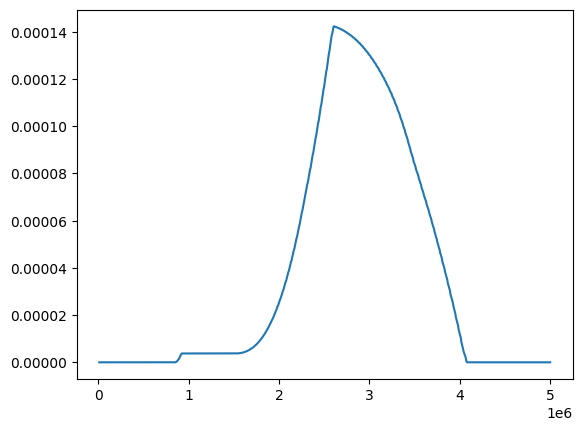

In [9]:
fuel.set_density('g/cm3',4.905)
neutron_intensities,neutron_energies,n_per_s_per_kg = an.neutron_spectra_from_material(fuel,E_min=1e4,nr_points=1000,nr_energies=1000,new_file=False)
neutron_intensities = np.clip(neutron_intensities,0,None)
energy = openmc.stats.Tabular(neutron_energies, neutron_intensities)

fig,ax =plt.subplots()

ax.plot(neutron_energies,neutron_intensities)

print(n_per_s_per_kg)

In [10]:
#Setting source and settings
def shell_vol_calc(geom_or,geom_ir):
    volume=4/3*np.pi*(geom_or**3-geom_ir**3)
    return volume
def set_source(material,innr_r,outer_r):
    print(f'\n\n {material.name}')
    n_intensities,n_energies,n_per_s_per_kg = an.neutron_spectra_from_material(material,E_min=1e4,
                                                                               nr_points=1000,nr_energies=1000,
                                                                               new_file=True)
    
    n_intensities = np.clip(n_intensities,0,None)
    energy = openmc.stats.Tabular(n_energies, n_intensities)
    
    material_vol = shell_vol_calc(outer_fuel_r,inner_fuel_r)
    material_mass = material.density*material_vol/1000
    total_n_per_s = n_per_s_per_kg*material_mass

    return openmc.IndependentSource(space=fuel_space, energy=energy,particle='neutron', strength=total_n_per_s)

inner_fuel_radius = geom.get_surfaces_by_name('fuel_inner')[0].bounding_box('-')[1][0]
outer_fuel_radius = geom.get_surfaces_by_name('fuel_outer')[0].bounding_box('-')[1][0]

inner_blanket_radius = geom.get_surfaces_by_name('blanket_inner')[0].bounding_box('-')[1][0]
outer_blanket_radius = geom.get_surfaces_by_name('blanket_outer')[0].bounding_box('-')[1][0]

fuel_space = openmc.stats.spherical_uniform(r_outer=outer_fuel_radius,r_inner=inner_fuel_radius)
blanket_space = openmc.stats.spherical_uniform(r_outer=outer_blanket_radius,r_inner=inner_blanket_radius)

#Getting materials
fuel = gh.get_material_by_name(fuel_name,materials)
blanket = gh.get_material_by_name('Blanket_CA',materials)

fuel_src = set_source(fuel,inner_fuel_radius,outer_fuel_radius)
blanket_src = set_source(blanket,inner_blanket_radius,outer_blanket_radius)

settings = openmc.Settings()
settings.run_mode = 'eigenvalue'
settings.source =  [fuel_src,blanket_src]   # evt. + SF-kilde som separat source
settings.batches = 50
settings.inactive = 10
settings.particles = 10000 # is changed later

#Fixing Li6 at 900 K doesn't have a cross section 
settings.temperature = {
    'method': 'nearest',
    'tolerance': 1000}

model_eigen = openmc.Model(geometry=geom, materials=materials, settings=settings)

model_eigen.run()



 Fuel_CA_2
SRIM perfekt threshold was not found using 7 isotopes
Writing SRIM file after 101 threshold tries
len target elements 7, #elements 7
SRModule done, length of data: 71 and 71
Getting cross sections...
Making kernels and integrent...
setup done in 4.190257969952654 s


 Blanket_CA
SRIM perfekt threshold was not found using 5 isotopes
Writing SRIM file after 101 threshold tries
len target elements 5, #elements 5
SRModule done, length of data: 71 and 71
Getting cross sections...
Making kernels and integrent...
setup done in 4.189648170955479 s
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%

PosixPath('/root/Speciale/statepoint.50.h5')

In [11]:
settings.run_mode = 'fixed source'
settings.batches = 10
settings.inactive = 0
settings.particles = 2000 

#Tallies
resolution_of_mesh=10
mesh_size = int(blanket_or)
os.system("rm tallies.xml")
# Tally 1: energy spectrum in fuel

fuel_cell = geom.get_cells_by_name('fuel')[0]
cell_filter1 = openmc.CellFilter(fuel_cell)
energybins=np.logspace(-2,7,1001) #1000 bins between 1e-2 eV and 1e7 eV
energy_filter = openmc.EnergyFilter(energybins)
    
t1 = openmc.Tally(1)
t1.filters = [cell_filter1,energy_filter]
t1.scores = ['flux']

# Tally 2: Materials flux
# Create mesh which will be used for tally
mesh = openmc.RegularMesh()
mesh.dimension = [mesh_size*resolution_of_mesh, mesh_size*resolution_of_mesh]
mesh.lower_left = [-mesh_size, -mesh_size]
mesh.upper_right = [mesh_size, mesh_size]

# Create mesh filter for tally
mesh_filter = openmc.MeshFilter(mesh)

t2 = openmc.Tally(2)
t2.filters = [mesh_filter]
t2.scores = ["flux","fission"] #flux

#implement both tallies
tallies = openmc.Tallies([t1,t2]) #tallies.append(tally) is also an option
print(tallies)
tallies.export_to_xml()

model_fixed = openmc.Model(geometry=geom, materials=materials, settings=settings,tallies=tallies)
model_fixed.run()

/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Tally instance already exists with id=1.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Tally instance already exists with id=2.
  warn(msg, IDWarning)


[Tally
	ID             =	1
	Name           =	
	Filters        =	CellFilter, EnergyFilter
	Nuclides       =	
	Scores         =	['flux']
	Estimator      =	None
	Multiply dens. =	True, Tally
	ID             =	2
	Name           =	
	Filters        =	MeshFilter
	Nuclides       =	
	Scores         =	['flux', 'fission']
	Estimator      =	None
	Multiply dens. =	True]
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%

KeyboardInterrupt: 

In [ ]:
#print(sp.tallies.keys())
def plotCircle(ax ,r ,mesh_size ,resolution, label=False):
    theta = np.linspace(0, 2*np.pi, 200)
    x = (r * np.cos(theta)+mesh_size)*resolution/2
    y = (r * np.sin(theta)+mesh_size)*resolution/2
    if label:
        ax.plot(x,y,'r--',alpha=0.2,label="edge of fuel shell")
    else:
        ax.plot(x,y,'r--',alpha=0.2)
    return (x,y)

with openmc.StatePoint(f'statepoint.{settings_dep.batches}.h5') as sp:
        tally = sp.get_tally(id=1)
        tally1 = sp.get_tally(id=2)
#print(tally)


flux = tally.get_slice(scores=['flux'])
fission = tally.get_slice(scores=['fission'])

flux.std_dev.shape = (mesh_size*resolution_of_mesh, mesh_size*resolution_of_mesh)
flux.mean.shape = (mesh_size*resolution_of_mesh, mesh_size*resolution_of_mesh)
fission.std_dev.shape = (mesh_size*resolution_of_mesh, mesh_size*resolution_of_mesh)
fission.mean.shape = (mesh_size*resolution_of_mesh, mesh_size*resolution_of_mesh)

#Setting up figures using gridspec
fig = plt.figure(figsize=(18,6))
gs = gridspec.GridSpec(1, 3, width_ratios=[1,1,1], wspace=0.4)



ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])

ax0.set_title("neutron flux\n [particle-cm/source particle]")
im0=ax0.imshow(flux.mean, origin='lower')
plotCircle(ax0, inner_fuel_radius, mesh_size, resolution_of_mesh)
plotCircle(ax0, outer_fuel_radius, mesh_size, resolution_of_mesh, label=True)

ax0.set_xlabel('x [mm]')
ax0.set_ylabel('y [mm]')
fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)
ax0.legend(loc='lower left')

ax1.set_title("fission neutron production\n [particles produced/source particle]")
im1=ax1.imshow(fission.mean, origin='lower')
plotCircle(ax1, inner_fuel_radius, mesh_size, resolution_of_mesh)
plotCircle(ax1, outer_fuel_radius, mesh_size, resolution_of_mesh, label=True)

ax1.set_xlabel('x [mm]')
ax1.set_ylabel('y [mm]')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
ax1.legend(loc='lower left')



# Create log-spaced energy bins from 1 keV to 10 MeV
energy_bins = np.logspace(3,7)

tally1=sp.get_tally(id=1)
#print(tally1.get_pandas_dataframe())

flux1 = tally1.get_pandas_dataframe()


ax2.plot(flux1['energy low [eV]'],flux1['mean'])

# Plot source energy PDF

ax2.set_xscale('log')  # log scale for x-axis
ax2.set_xlabel('Energy (eV)')
ax2.set_ylabel('Flux (particle-cm per source particle)')
ax2.set_title("Neutron energy in fuel")
#ax2.set_title("Neutron energy in moderator")
pos = ax0.get_position()  # returns [left, bottom, width, height]
pos2 = ax2.get_position()
# Set ax2 to have the same vertical position/height
ax2.set_position([pos2.x0, pos.y0, pos.width, pos.height])

total_fission_n = sum(sum(fission.mean))
print(f"total fission neutrons {total_fission_n:.4g}")

In [ ]:
#print(cells)
#print(fuel_material)
fuel_cell = geom.get_cells_by_name('fuel')[0]
moderator_cell = geom.get_cells_by_name('moderator')[0]
blanket_cell = geom.get_cells_by_name('blanket')[0]
air_cell = geom.get_cells_by_name('air')[0]

inner_fuel_radius = geom.get_surfaces_by_name('fuel_inner')[0].bounding_box('-')[1][0]
outer_fuel_radius = geom.get_surfaces_by_name('fuel_outer')[0].bounding_box('-')[1][0]
outer_radius = geom.get_surfaces_by_name('blanket_outer')[0].bounding_box('-')[1][0]
print(geom.get_surfaces_by_name('blanket_outer')[0].bounding_box('-'))
print(f'fuel radius and outer radius are {inner_fuel_radius}, {outer_fuel_radius} and  {outer_radius}')

cell_colors = {
    fuel_cell: 'red',
    moderator_cell: 'blue',
    air_cell: "lightgrey",
    blanket_cell: 'black'
    }


geom.plot(
    pixels=(400, 400),       # resolution
    basis='xy',              # plane (xy, xz, yz)
    color_by='cell',     # color by material or cell
    colors = cell_colors
    )